In [1]:
from sklearn.datasets import load_iris

iris = load_iris()

In [2]:
print(iris.data.shape, type(iris.data.shape))
print(iris.target.shape, type(iris.target.shape))
print(iris.feature_names, type(iris.feature_names))
print(iris.target_names, type(iris.target_names))

(150, 4) <class 'tuple'>
(150,) <class 'tuple'>
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)'] <class 'list'>
['setosa' 'versicolor' 'virginica'] <class 'numpy.ndarray'>


In [3]:
iris.data[:5]

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2]])

In [4]:
iris.target[:5]

array([0, 0, 0, 0, 0])

In [5]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

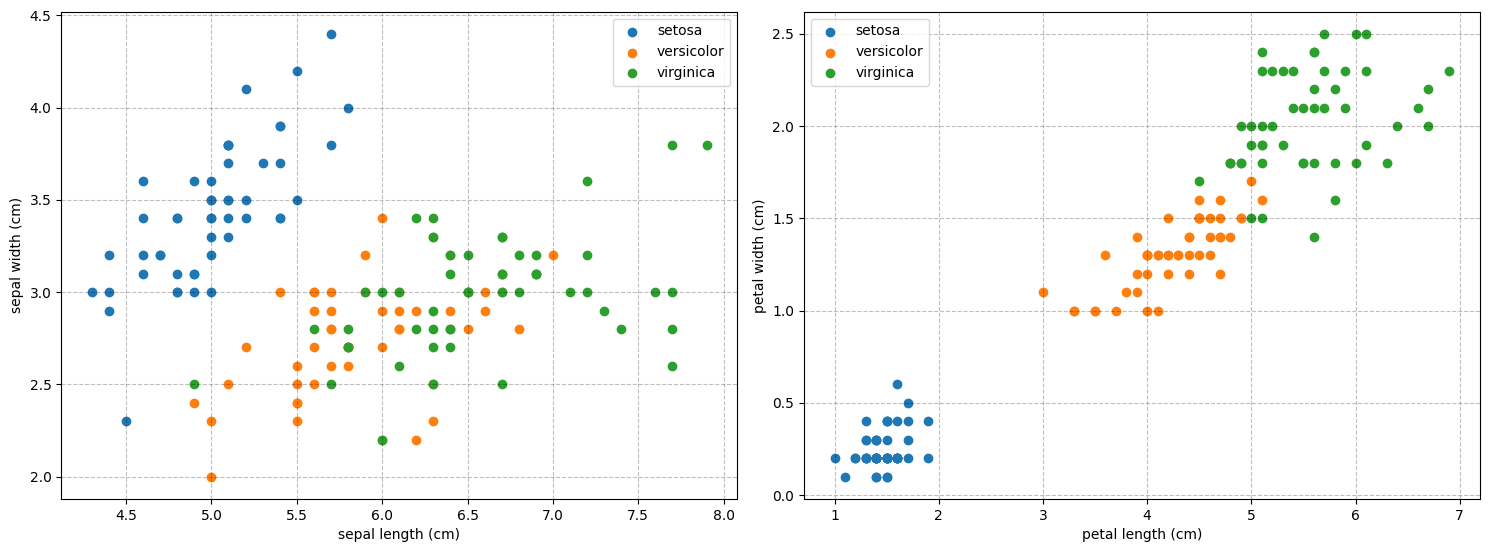

In [6]:
from matplotlib import pyplot as plt


def scatter_plot_by_label(bunch, x=0, y=1, ax=None, legend=False):
    ax = plt.gca() if ax is None else ax
    for i, name in enumerate(bunch.target_names):
        ax.scatter(
            bunch.data[bunch.target == i, x],
            bunch.data[bunch.target == i, y],
            label=name,
        )
        ax.set_xlabel(bunch.feature_names[x])
        ax.set_ylabel(bunch.feature_names[y])
        ax.grid(True, color="black", linestyle="--", alpha=0.25)
        if legend:
            ax.legend()


fig, axs = plt.subplots(1, 2, figsize=(15, 10 * 9 / 16), tight_layout=True)
scatter_plot_by_label(iris, 0, 1, axs[0], legend=True)
scatter_plot_by_label(iris, 2, 3, axs[1], legend=True)
plt.show()

In [7]:
import numpy as np


def train_test_split(x, y, train_size=0.8, random_state=None):
    RNG = np.random.default_rng(random_state)
    N = len(x)
    n_train = round(N * train_size)
    idx_train = RNG.choice(N, n_train, replace=False)
    idx_test = np.setdiff1d(np.arange(N), idx_train)
    RNG.shuffle(idx_test)
    return x[idx_train], x[idx_test], y[idx_train], y[idx_test]


x_train, x_test, y_train, y_test = train_test_split(
    iris.data, iris.target, train_size=0.8, random_state=1
)

In [8]:
from scipy.spatial import KDTree
from scipy.stats import mode


class KNNC:
    def __init__(self, k):
        self.k = k

    def fit(self, x, y):
        self.y_train_ = y
        self.x_train_kdt_ = KDTree(x)
        return self

    def predict(self, x):
        _, neighbors = self.x_train_kdt_.query(x, k=self.k)
        neighbors = neighbors.reshape(len(x), self.k)
        neighbor_labels = self.y_train_[neighbors]
        m, _ = mode(neighbor_labels, axis=1, keepdims=False)
        return m

In [9]:
knn = KNNC(k=3)
knn.fit(x_train, y_train)
y_hat_test = knn.predict(x_test)
y_hat_test

array([0, 1, 2, 0, 0, 2, 0, 0, 2, 0, 1, 2, 1, 2, 1, 0, 2, 1, 0, 0, 1, 1,
       2, 1, 2, 2, 1, 0, 1, 1])

In [10]:
def error_rate(y, y_hat):
    n = len(y)
    sum_of_errors = sum(y != y_hat)
    return sum_of_errors / n


y_hat_train = knn.predict(x_train)
error_rate(y_train, y_hat_train), error_rate(y_test, y_hat_test)

(np.float64(0.041666666666666664), np.float64(0.03333333333333333))

In [11]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_hat_test)
cm

array([[10,  0,  0],
       [ 0, 10,  0],
       [ 0,  1,  9]])

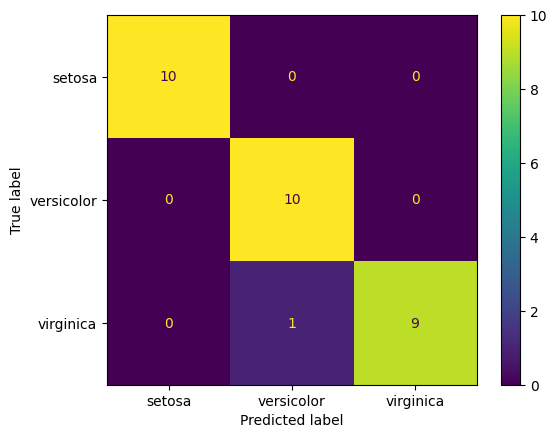

In [12]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(cm, display_labels=iris.target_names).plot()
plt.show()

In [13]:
error_rates_train = []
error_rates_test = []

max_k = 60
for k in range(1, max_k + 1):
    knn = KNNC(k).fit(x_train, y_train)
    error_rates_train.append(error_rate(y_train, knn.predict(x_train)))
    error_rates_test.append(error_rate(y_test, knn.predict(x_test)))

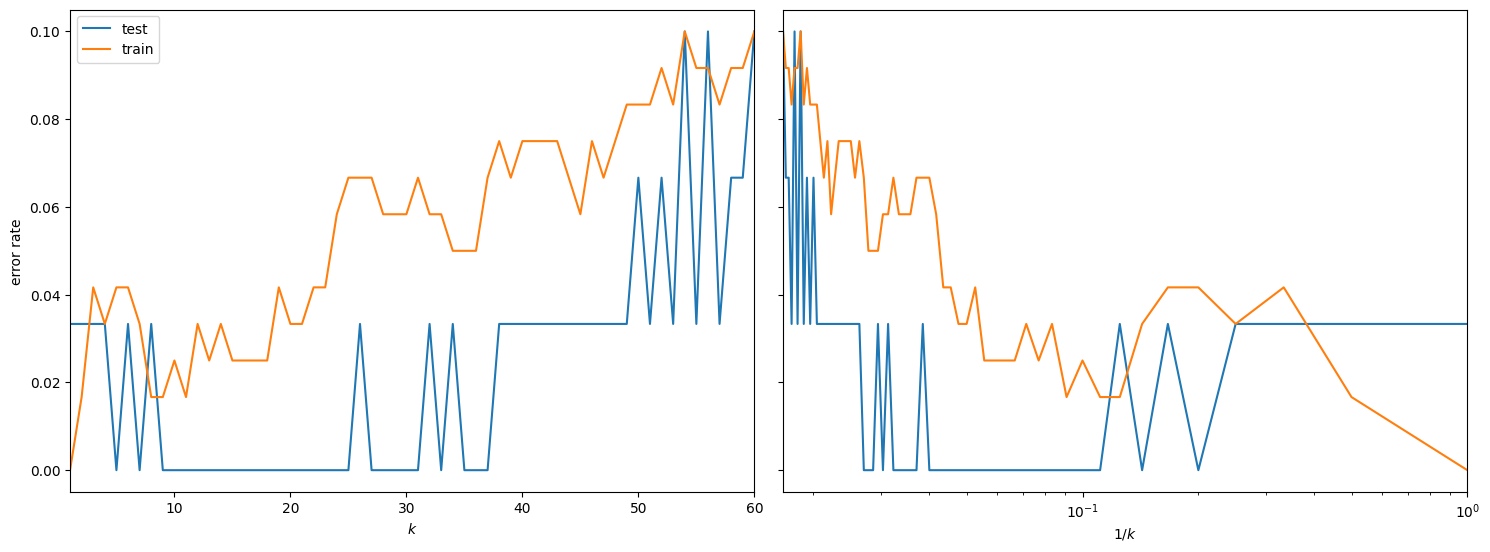

In [15]:
_, axs = plt.subplots(1, 2, figsize=(15, 10 * 9 / 16), tight_layout=True, sharey=True)
ks = np.arange(1, max_k + 1)
axs[0].plot(ks, error_rates_test, label="test")
axs[0].plot(ks, error_rates_train, label="train")
axs[0].margins(x=0)
axs[0].set_ylabel("error rate")
axs[0].set_xlabel("$k$")
axs[0].legend()
axs[1].plot(1 / ks, error_rates_test)
axs[1].plot(1 / ks, error_rates_train)
axs[1].margins(x=0)
axs[1].set_xlabel("$1/k$")
axs[1].set_xscale("log")
plt.show()